# 05 - Model Evaluation & Saving

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
results_df = pd.read_csv('../data/processed/model_results.csv', index_col=0)
results_df

,MAE,RMSE,R2
Linear Regression,5.899583,8.821909,0.826369
Random Forest,6.820450,9.796870,0.785870
Gradient Boosting,6.546289,9.423666,0.801874


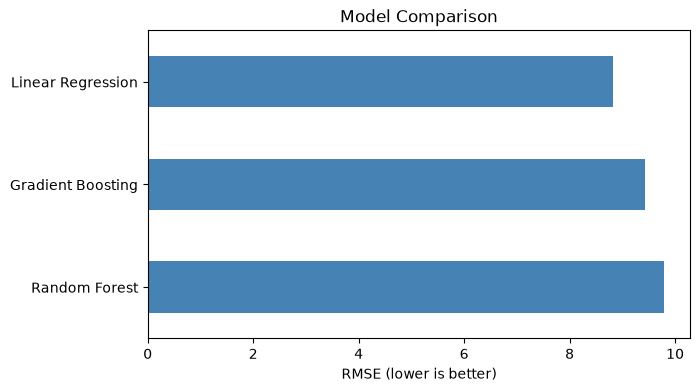

In [3]:
results_df['RMSE'].sort_values().plot(kind='barh', figsize=(7,4), color='steelblue')
plt.xlabel('RMSE (lower is better)')
plt.title('Model Comparison')
plt.gca().invert_yaxis()
plt.show()

Picking whichever model has the lowest RMSE instead of assuming, keeps this notebook correct even if the numbers change on a rerun.

In [4]:
best_name = results_df['RMSE'].idxmin()
best_name

'Linear Regression'

In [5]:
model_lookup = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

final_model = model_lookup[best_name]

Retraining the chosen model on the full training set.

In [6]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

final_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 3. , 5.58, 0.97,...,-1.36, 0.52,-0.93]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Distance_km','Traffic_Level','Preparation_Time_min',..., 'Time_of_Day_Night','Vehicle_Type_Car','Vehicle_Type_Scooter']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [7]:
preds = final_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, preds))
print('RMSE:', np.sqrt(mean_squared_error(y_test, preds)))
print('R2:', r2_score(y_test, preds))

MAE: 5.899582676018096
RMSE: 8.821909258797255
R2: 0.826369033299585


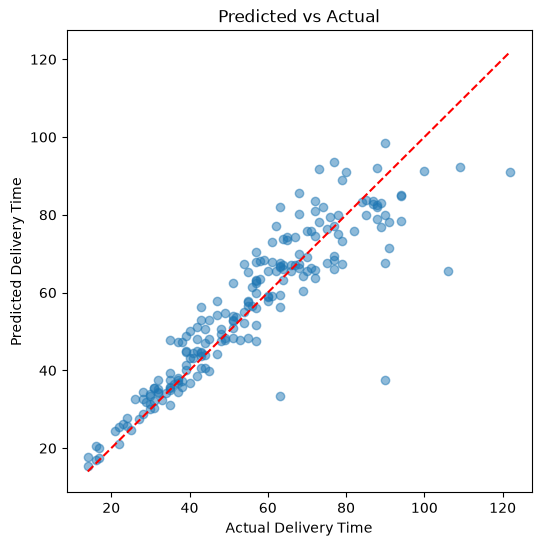

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Predicted vs Actual')
plt.show()

Feature importance only makes sense for the tree-based models, using the coefficients instead if Linear Regression won.

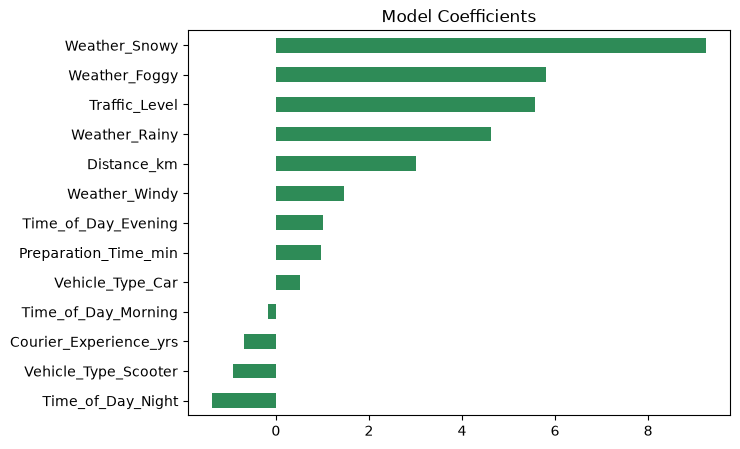

In [9]:
if hasattr(final_model, 'feature_importances_'):
    scores = pd.Series(final_model.feature_importances_, index=X_train.columns)
    title = 'Feature Importance'
else:
    scores = pd.Series(final_model.coef_, index=X_train.columns)
    title = 'Model Coefficients'

scores.sort_values().plot(kind='barh', figsize=(7,5), color='seagreen')
plt.title(title)
plt.show()

Saving the trained model and the column order, need the same columns at prediction time.

In [10]:
with open('../models/food_delivery_model.pkl', 'wb') as f:
    pickle.dump({'model': final_model, 'columns': list(X_train.columns)}, f)